In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [3]:
data = pd.read_csv(r"C:\Users\rahul\Documents\Programming\Github Projects\Classic-ML-Projects\customer-segmentation-via-clustering\data\customer_data.csv")

In [4]:
data.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [5]:
data.isnull().sum()

Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

In [6]:
data.duplicated().sum()

np.int64(0)

In [7]:
data.drop(columns=['Channel', 'Region'], inplace=True)

In [8]:
data.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,12669,9656,7561,214,2674,1338
1,7057,9810,9568,1762,3293,1776
2,6353,8808,7684,2405,3516,7844
3,13265,1196,4221,6404,507,1788
4,22615,5410,7198,3915,1777,5185


In [9]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Fresh             440 non-null    int64
 1   Milk              440 non-null    int64
 2   Grocery           440 non-null    int64
 3   Frozen            440 non-null    int64
 4   Detergents_Paper  440 non-null    int64
 5   Delicassen        440 non-null    int64
dtypes: int64(6)
memory usage: 20.8 KB


In [10]:
data.corr()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Fresh,1.000000,0.100510,-0.011854,0.345881,-0.101953,0.244690
Milk,0.100510,1.000000,0.728335,0.123994,0.661816,0.406368
Grocery,-0.011854,0.728335,1.000000,-0.040193,0.924641,0.205497
Frozen,0.345881,0.123994,-0.040193,1.000000,-0.131525,0.390947
Detergents_Paper,-0.101953,0.661816,0.924641,-0.131525,1.000000,0.069291
Delicassen,0.244690,0.406368,0.205497,0.390947,0.069291,1.000000


In [11]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Fresh,440.0,12000.297727,12647.328865,3.0,3127.75,8504.0,16933.75,112151.0
Milk,440.0,5796.265909,7380.377175,55.0,1533.00,3627.0,7190.25,73498.0
Grocery,440.0,7951.277273,9503.162829,3.0,2153.00,4755.5,10655.75,92780.0
Frozen,440.0,3071.931818,4854.673333,25.0,742.25,1526.0,3554.25,60869.0
Detergents_Paper,440.0,2881.493182,4767.854448,3.0,256.75,816.5,3922.00,40827.0
Delicassen,440.0,1524.870455,2820.105937,3.0,408.25,965.5,1820.25,47943.0


In [12]:
for col in data.columns:
    print(f"{col}: {data[col].nunique()} unique values")

Fresh: 433 unique values
Milk: 421 unique values
Grocery: 430 unique values
Frozen: 426 unique values
Detergents_Paper: 417 unique values
Delicassen: 403 unique values


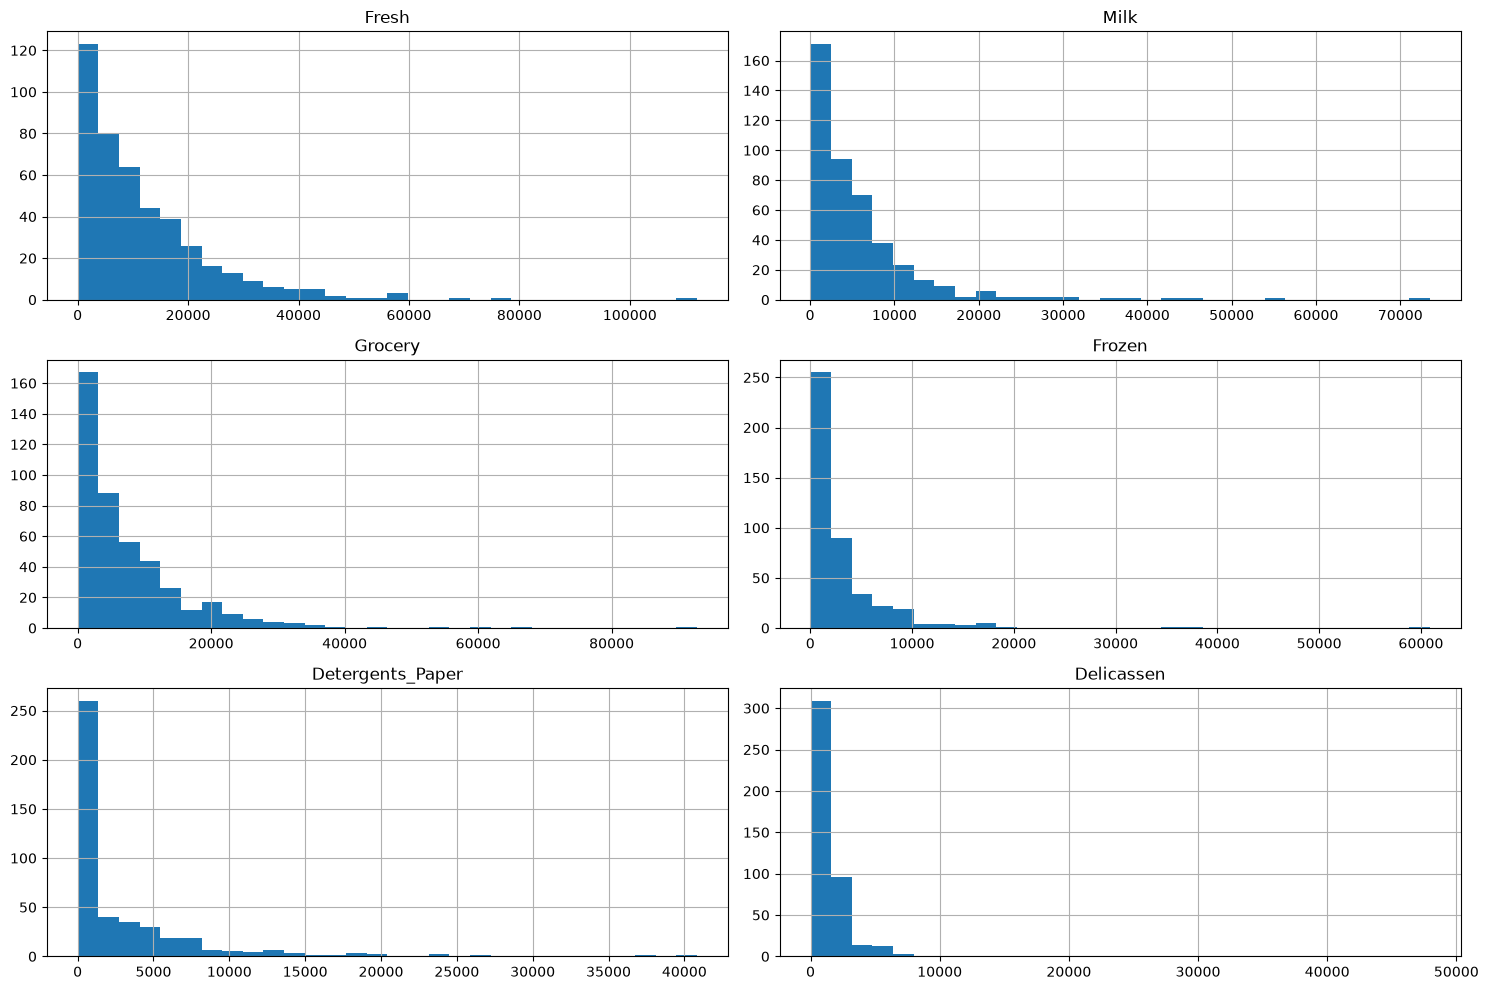

In [13]:
data.hist(figsize=(15,10), bins=30)

plt.tight_layout()
plt.show()

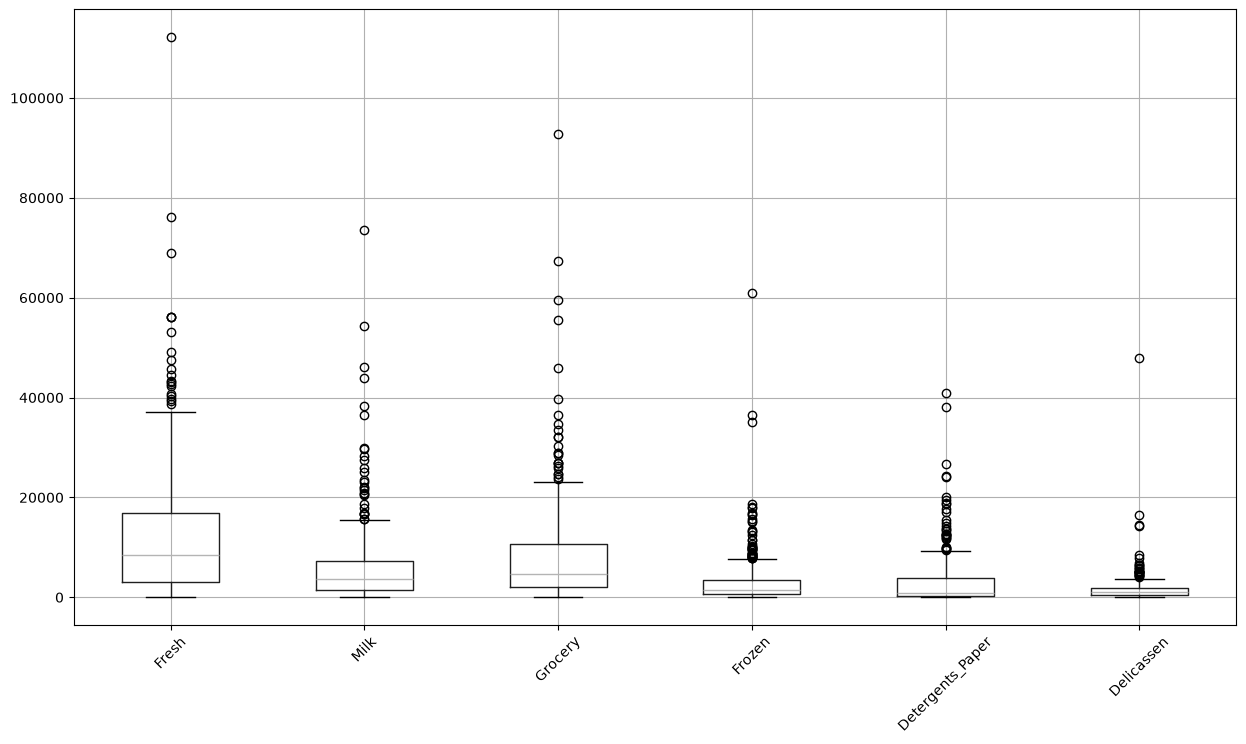

In [14]:
plt.figure(figsize=(15,8))

data.boxplot(rot=45)

plt.show()

In [15]:
data.skew(numeric_only=True)

Fresh                2.561323
Milk                 4.053755
Grocery              3.587429
Frozen               5.907986
Detergents_Paper     3.631851
Delicassen          11.151586
dtype: float64

In [16]:
data_log = pd.DataFrame(np.log1p(data), columns=data.columns, index=data.index)

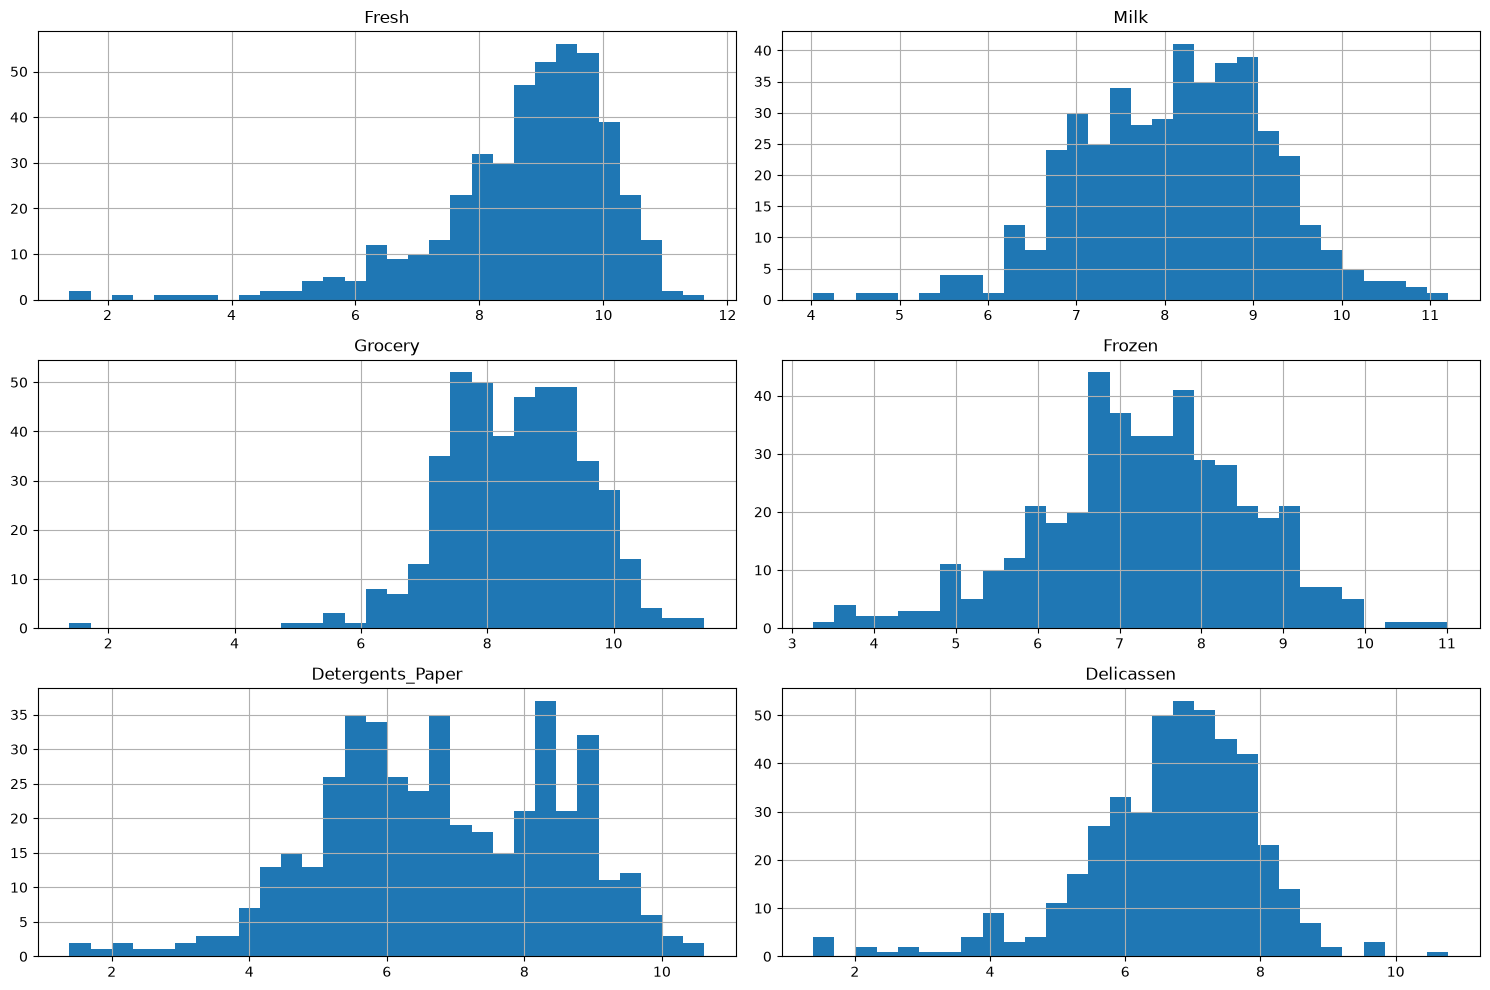

In [17]:
data_log.hist(figsize=(15,10), bins=30)

plt.tight_layout()
plt.show()

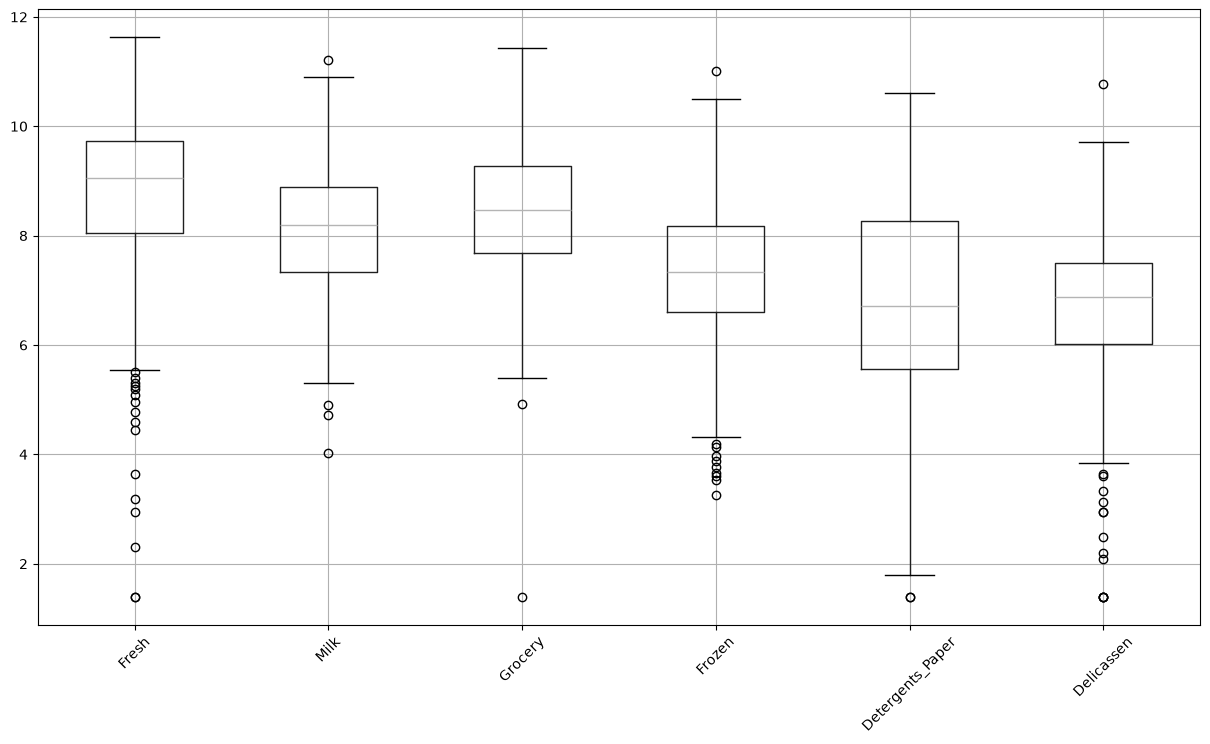

In [18]:
plt.figure(figsize=(15,8))

data_log.boxplot(rot=45)

plt.show()

In [19]:
print(data_log.skew())

Fresh              -1.575326
Milk               -0.224063
Grocery            -0.674938
Frozen             -0.352655
Detergents_Paper   -0.235961
Delicassen         -1.091827
dtype: float64


In [20]:
scaler = StandardScaler()

In [21]:
data_scaled = scaler.fit_transform(data_log)

In [22]:
data_scaled

array([[ 0.4861845 ,  0.97629884,  0.44015468, -1.50924981,  0.64414327,
         0.40896595],
       [ 0.08788863,  0.99095612,  0.65217085,  0.13405226,  0.76604314,
         0.62792606],
       [ 0.01635628,  0.89115098,  0.45468702,  0.37689926,  0.80440496,
         1.77683339],
       ...,
       [ 0.57952767,  1.41399051,  1.68865731, -0.95351417,  1.64761948,
         0.66656608],
       [ 0.34460869, -0.49078257, -0.65849797, -0.27890118, -0.97324089,
         0.76666284],
       [-0.54442663, -0.63351532, -0.55281539, -2.43158276, -0.36435895,
        -2.0896139 ]], shape=(440, 6))

In [23]:
wcss = []

In [24]:
for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(data_scaled)

    wcss.append(kmeans.inertia_)

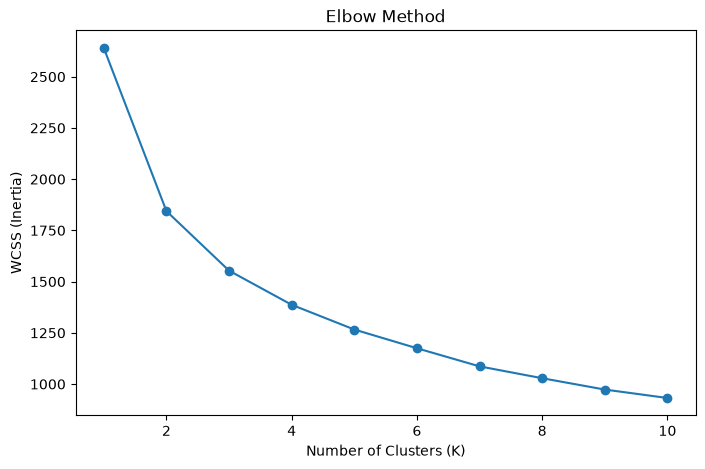

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Inertia)")
plt.title("Elbow Method")

plt.show()

In [26]:
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(data_scaled)

    score = silhouette_score(data_scaled, labels)

    silhouette_scores.append(score)

    print(f"K = {k}, Silhouette Score = {score:.4f}")

K = 2, Silhouette Score = 0.2903
K = 3, Silhouette Score = 0.2594
K = 4, Silhouette Score = 0.1885
K = 5, Silhouette Score = 0.1916
K = 6, Silhouette Score = 0.2009
K = 7, Silhouette Score = 0.1958
K = 8, Silhouette Score = 0.1852
K = 9, Silhouette Score = 0.1965
K = 10, Silhouette Score = 0.1905


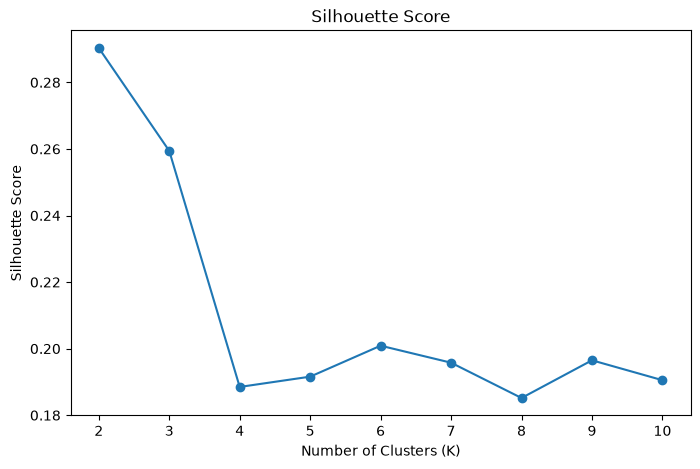

In [27]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    silhouette_scores,
    marker='o'
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score")

plt.show()

In [29]:
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

labels = kmeans.fit_predict(data_scaled)

In [30]:
print(labels)

[1 1 1 0 1 1 1 1 1 1 1 0 1 1 1 0 1 0 1 1 1 0 0 1 1 1 0 0 1 0 1 0 0 0 0 1 0
 1 1 0 0 1 1 1 1 1 1 1 1 1 0 1 1 1 0 1 1 1 0 1 1 1 1 1 0 1 1 1 1 0 0 1 0 0
 1 0 0 1 0 1 0 1 1 0 1 1 1 1 0 0 0 0 1 0 1 1 1 0 0 0 1 1 1 0 0 0 1 1 1 1 0
 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 1 0 0 0 0 0 0 0 1 1 0 0 1 0 0 0 0 1 0 0
 0 0 0 0 0 0 0 1 1 0 1 1 1 0 0 1 1 1 1 1 0 0 1 1 1 1 0 1 0 0 0 0 1 1 1 1 0
 0 0 1 1 1 0 0 0 1 0 0 0 1 0 0 1 1 1 0 0 1 0 1 1 1 0 1 0 1 1 1 1 0 1 0 0 1
 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 1 0 1 1 0 0 0 0
 0 0 0 0 0 1 1 1 0 1 0 0 0 1 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0
 0 1 1 0 1 1 1 1 1 1 1 0 0 1 0 0 1 0 0 1 0 1 0 1 0 0 0 0 0 1 0 0 0 0 0 1 0
 1 0 1 0 0 0 0 1 1 1 1 0 1 1 1 0 1 0 1 0 1 0 0 0 1 1 0 0 0 0 0 0 1 0 0 0 0
 0 0 0 1 0 0 1 0 0 1 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0
 1 1 1 0 0 1 0 0 1 1 1 1 0 1 1 0 0 1 0 1 0 1 0 1 0 0 0 1 1 0 1 0 0]


In [31]:
data_original = np.expm1(data_log)

In [32]:
data_original.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,12669.0,9656.0,7561.0,214.0,2674.0,1338.0
1,7057.0,9810.0,9568.0,1762.0,3293.0,1776.0
2,6353.0,8808.0,7684.0,2405.0,3516.0,7844.0
3,13265.0,1196.0,4221.0,6404.0,507.0,1788.0
4,22615.0,5410.0,7198.0,3915.0,1777.0,5185.0


In [33]:
data_clustered = data_original.copy()

data_clustered['Cluster'] = labels

In [34]:
data_clustered.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Cluster
0,12669.0,9656.0,7561.0,214.0,2674.0,1338.0,1
1,7057.0,9810.0,9568.0,1762.0,3293.0,1776.0,1
2,6353.0,8808.0,7684.0,2405.0,3516.0,7844.0,1
3,13265.0,1196.0,4221.0,6404.0,507.0,1788.0,0
4,22615.0,5410.0,7198.0,3915.0,1777.0,5185.0,1


In [35]:
data_clustered['Cluster'].value_counts()

Cluster
0    252
1    188
Name: count, dtype: int64

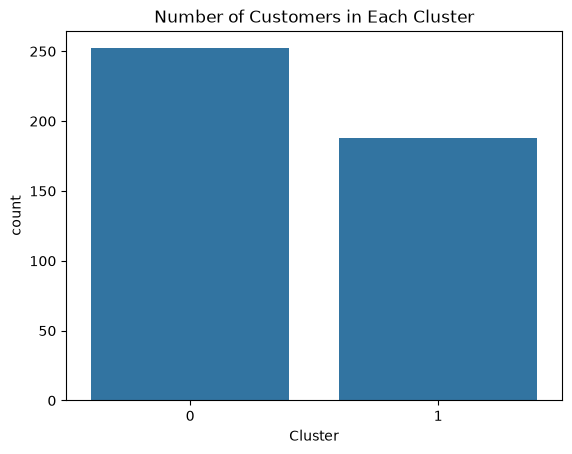

In [36]:
sns.countplot(x='Cluster', data=data_clustered)

plt.title("Number of Customers in Each Cluster")
plt.show()

In [37]:
cluster_profile = data_clustered.groupby('Cluster').mean()

cluster_profile

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Cluster,,,,,,
0,13973.126984,2401.750000,2918.706349,3705.670635,491.944444,1038.043651
1,9355.867021,10346.361702,14697.063830,2222.452128,6084.505319,2177.425532


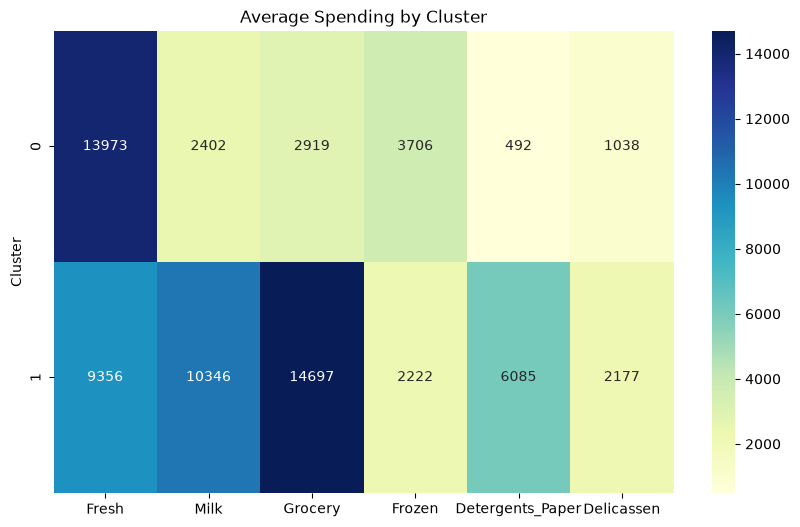

In [38]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    cluster_profile,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Average Spending by Cluster")
plt.show()

In [39]:
final_silhouette = silhouette_score(data_scaled, labels)

print(f"Final Silhouette Score: {final_silhouette:.4f}")

Final Silhouette Score: 0.2903


In [40]:
cluster_distribution = (
    data_clustered['Cluster']
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

print(cluster_distribution)

Cluster
0    57.272727
1    42.727273
Name: proportion, dtype: float64
